In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error
import joblib
import os

# =========================================================
# CONFIGURACIÓN EXPERIMENTO
# =========================================================

delta = 10  # pasos al futuro 
usar_solo_posicion = False  # True = (x,y) | False = (x,y,v,a)

# Selección de puntos

# Cambiar según prueba
# Prueba 9 puntos: [1, 4, 5, 6, 8, 9, 10, 11, 12]
# Prueba 6 puntos: [1, 4, 5, 9, 10, 12]
# Prueba 4 puntos: [1, 4, 10, 12]
puntos_a_mantener = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]  




In [12]:

# =========================================================
# RUTAS
# =========================================================

carpeta_features = "Tracking_Features_ML_Color"

carpeta_principal = "DATASET"

carpetas_simulacion = [
    # --- FASE 1 ---
    f"{carpeta_principal}/Dataset_Fase1_Tp6",
    f"{carpeta_principal}/Dataset_Fase1_Tp8",
    f"{carpeta_principal}/Dataset_Fase1_Tp10",
    f"{carpeta_principal}/Dataset_Fase1_Tp12",
    # --- FASE 2 ---
    f"{carpeta_principal}/Dataset_Fase2_Tp6",
    f"{carpeta_principal}/Dataset_Fase2_Tp8",
    f"{carpeta_principal}/Dataset_Fase2_Tp10",
    f"{carpeta_principal}/Dataset_Fase2_Tp12",
    # --- FASE 3 ---
    *[f"{carpeta_principal}/Dataset_Fase3_Hs{hs}_Tp{tp}_H{h}" 
      for hs in [0.5, 1.5, 3.0, 5.0] 
      for tp in [6, 8, 10, 12, 14] 
      for h  in [0, 90, 135, 180]],
]

# caja fuerte
carpetas_validacion = [
    f"{carpeta_principal}/Dataset_Fase4_Tp7",
    f"{carpeta_principal}/Dataset_Fase4_Tp9",
    f"{carpeta_principal}/Dataset_Fase4_Tp11",
    f"{carpeta_principal}/Dataset_Fase4_Tp13"
]

columnas_y = ['surge_px', 'heave_px', 'sway_m', 'rot_deg', 'yaw_deg', 'roll_deg']


In [13]:
# =========================================================
# CARGA Y PREPROCESAMIENTO
# =========================================================

all_train_X = []
all_train_y = []
datos_prueba = {}

archivos_feat = [f for f in os.listdir(carpeta_features) if f.startswith("feat_")]

for f_feat in archivos_feat:
    nombre_base = f_feat.replace("feat_", "").replace(".csv", "")
    path_feat = os.path.join(carpeta_features, f_feat)

    path_sim = None
    es_validacion = False

    # 1. busqueda en carpetas de ENTRENAMIENTO
    for carpeta in carpetas_simulacion:
        posible_path = os.path.join(carpeta, f"{nombre_base}.csv")
        if os.path.exists(posible_path):
            path_sim = posible_path
            es_validacion = False # Etiquetamos como dato de entrenamiento
            break

    # 2. busqueda en carpetas de VALIDACIÓN
    if not path_sim:
        for carpeta in carpetas_validacion:
            posible_path = os.path.join(carpeta, f"{nombre_base}.csv")
            if os.path.exists(posible_path):
                path_sim = posible_path
                es_validacion = True # Etiquetamos como dato de examen final
                break

    # si no está, se salta
    if not path_sim:
        continue

    df_feat = pd.read_csv(path_feat)
    df_sim = pd.read_csv(path_sim)

    # -----------------------------------------------------
    # Alinear tiempo
    # -----------------------------------------------------
    df_feat['tiempo'] = df_feat['tiempo'].round(3)
    df_sim['time_s'] = df_sim['time_s'].round(3)

    df_unido = pd.merge_asof(
        df_feat.sort_values('tiempo'),
        df_sim.sort_values('time_s'),
        left_on='tiempo', right_on='time_s',
        direction='nearest'
    )

    # -----------------------------------------------------
    # PREDICCIÓN A FUTURO
    # -----------------------------------------------------
    df_unido[columnas_y] = df_unido[columnas_y].shift(-delta)
    df_unido = df_unido.dropna().reset_index(drop=True)

    # -----------------------------------------------------
    # Columnas X originales
    # -----------------------------------------------------
    columnas_X = [
        col for col in df_unido.columns
        if col not in columnas_y and col not in ['tiempo', 'time_s']
    ]

    # -----------------------------------------------------
    # REDUCCIÓN DE PUNTOS
    # -----------------------------------------------------
    indices_a_mantener = []
    for p in puntos_a_mantener:
        inicio = (p - 1) * 6
        if usar_solo_posicion:
            indices_a_mantener.extend([inicio, inicio+1])
        else:
            indices_a_mantener.extend([inicio, inicio+1, inicio+2, inicio+3, inicio+4, inicio+5])

    columnas_X_reducidas = [columnas_X[i] for i in indices_a_mantener]

    X_base = df_unido[columnas_X_reducidas].values
    y_base = df_unido[columnas_y].values
    tiempo_base = df_unido['tiempo'].values

    # -----------------------------------------------------
    # VENTANAS TEMPORALES
    # -----------------------------------------------------
    window = 10
    X_windows = []
    y_windows = []

    for i in range(window, len(X_base)):
        Xw = X_base[i-window:i].flatten()
        yw = y_base[i]
        X_windows.append(Xw)
        y_windows.append(yw)

    X_windows = np.array(X_windows)
    y_windows = np.array(y_windows)
    tiempo_windows = tiempo_base[window:]

    # -----------------------------------------------------
    # TRAIN / TEST SPLIT AUTOMÁTICO POR CARPETA
    # -----------------------------------------------------
    if es_validacion:
        # a la caja fuerte
        datos_prueba[nombre_base] = {
            'X': X_windows,
            'y': y_windows,
            'tiempo': tiempo_windows
        }
    else:
        # a entrenamiento
        all_train_X.append(X_windows)
        all_train_y.append(y_windows)

# =========================================================
# DATASET FINAL
# =========================================================

X_train = np.vstack(all_train_X)
y_train = np.vstack(all_train_y)

print(f" Datos de entrenamiento: {X_train.shape}")
print(f" Features por muestra: {X_train.shape[1]}")
print(f" Videos en Validación (Fase 4): {list(datos_prueba.keys())}")


 Datos de entrenamiento: (652904, 720)
 Features por muestra: 720
 Videos en Validación (Fase 4): ['sway_amp_1_0_Tp13_sinusoidal', 'sway_amp_3_0_Tp13_sinusoidal', 'sway_amp_3_0_Tp9_sinusoidal', 'heave_amp_1_0_Tp9_sinusoidal', 'surge_amp_3_0_Tp7_sinusoidal', 'sway_amp_3_0_Tp11_sinusoidal', 'sway_amp_3_0_Tp7_sinusoidal', 'sway_amp_1_0_Tp11_sinusoidal', 'heave_amp_1_0_Tp7_sinusoidal', 'surge_amp_3_0_Tp9_sinusoidal', 'heave_amp_1_0_Tp13_sinusoidal', 'surge_amp_1_0_Tp13_sinusoidal', 'heave_amp_3_0_Tp13_sinusoidal', 'surge_amp_3_0_Tp13_sinusoidal', 'surge_amp_3_0_Tp11_sinusoidal', 'sway_amp_1_0_Tp7_sinusoidal', 'surge_amp_1_0_Tp9_sinusoidal', 'heave_amp_3_0_Tp7_sinusoidal', 'heave_amp_3_0_Tp11_sinusoidal', 'sway_amp_1_0_Tp9_sinusoidal', 'surge_amp_1_0_Tp11_sinusoidal', 'surge_amp_1_0_Tp7_sinusoidal', 'heave_amp_1_0_Tp11_sinusoidal', 'heave_amp_3_0_Tp9_sinusoidal']


In [14]:
print(X_train.shape)
print(type(X_train))

(652904, 720)
<class 'numpy.ndarray'>


In [ ]:
# =========================================================
# ENTRENAMIENTO RANDOM FOREST 
# =========================================================

modelo = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=30,      
        max_depth=12,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42
    )
)

modelo.fit(X_train, y_train)

nombre_modelo = f"modelo_{len(puntos_a_mantener)}pts_delta{delta}.pkl"
joblib.dump(modelo, nombre_modelo)



print("OK, Modelo entrenado")


In [ ]:
# =========================================================
# EVALUACIÓN PARES SIMILES
# =========================================================

def willmott(y_true, y_pred):
    mean = np.mean(y_true)
    num = np.sum((y_true - y_pred)**2)
    den = np.sum((np.abs(y_pred - mean) + np.abs(y_true - mean))**2)
    return 1 - num/den if den != 0 else 0

video_test = "video_Heave_Pitch_8_1.0_5.0"

X_test = datos_prueba[video_test]['X']
y_test = datos_prueba[video_test]['y']
t = datos_prueba[video_test]['tiempo']

y_pred = modelo.predict(X_test)

nombres = ["Surge","Heave","Sway","Pitch","Yaw","Roll"]

fig, axes = plt.subplots(3,2, figsize=(14,10))
axes = axes.ravel()

for i in range(6):
    rmse = np.sqrt(mean_squared_error(y_test[:,i], y_pred[:,i]))
    w = willmott(y_test[:,i], y_pred[:,i])

    axes[i].plot(t, y_test[:,i], 'k', label="Real")
    axes[i].plot(t, y_pred[:,i], 'r--', label="Pred")
    axes[i].set_title(f"{nombres[i]} | RMSE={rmse:.3f} | W={w:.3f}")
    axes[i].grid()
    axes[i].legend()

plt.tight_layout()
plt.show()

# ZOOM PARA VER DETALLES
start = 1000
end = 1500

fig2, axes2 = plt.subplots(3,2, figsize=(14,10))
axes2 = axes2.ravel()

for i in range(6):
    axes2[i].plot(t[start:end], y_test[start:end,i], 'k', label="Real")
    axes2[i].plot(t[start:end], y_pred[start:end,i], 'r--', label="Pred")
    axes2[i].set_title(f"{nombres[i]} (zoom)")
    axes2[i].grid()
    axes2[i].legend()

plt.tight_layout()
plt.show()

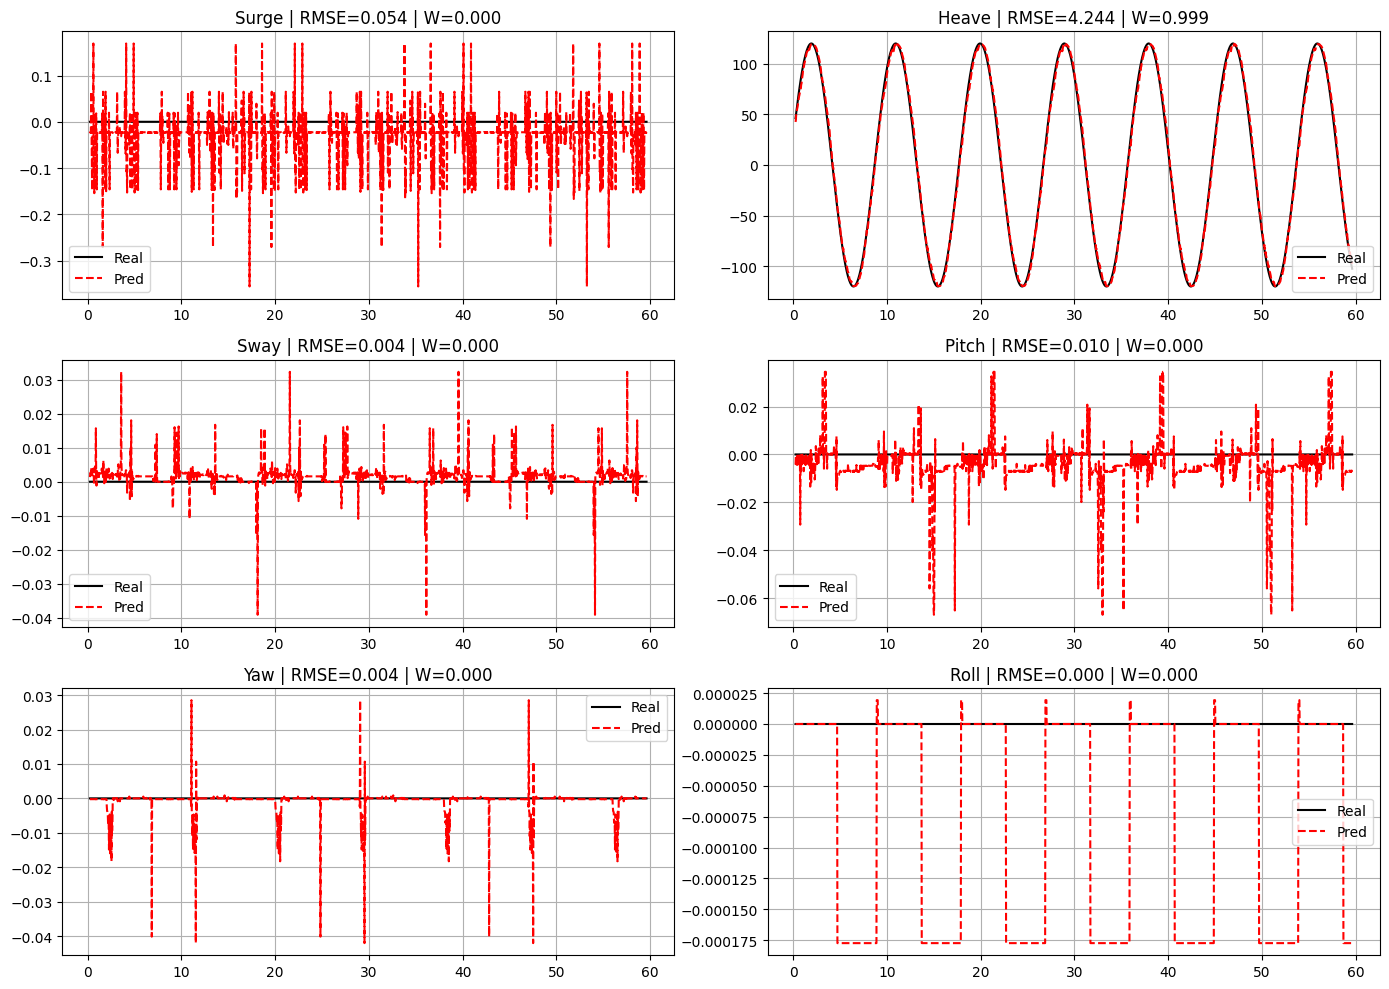

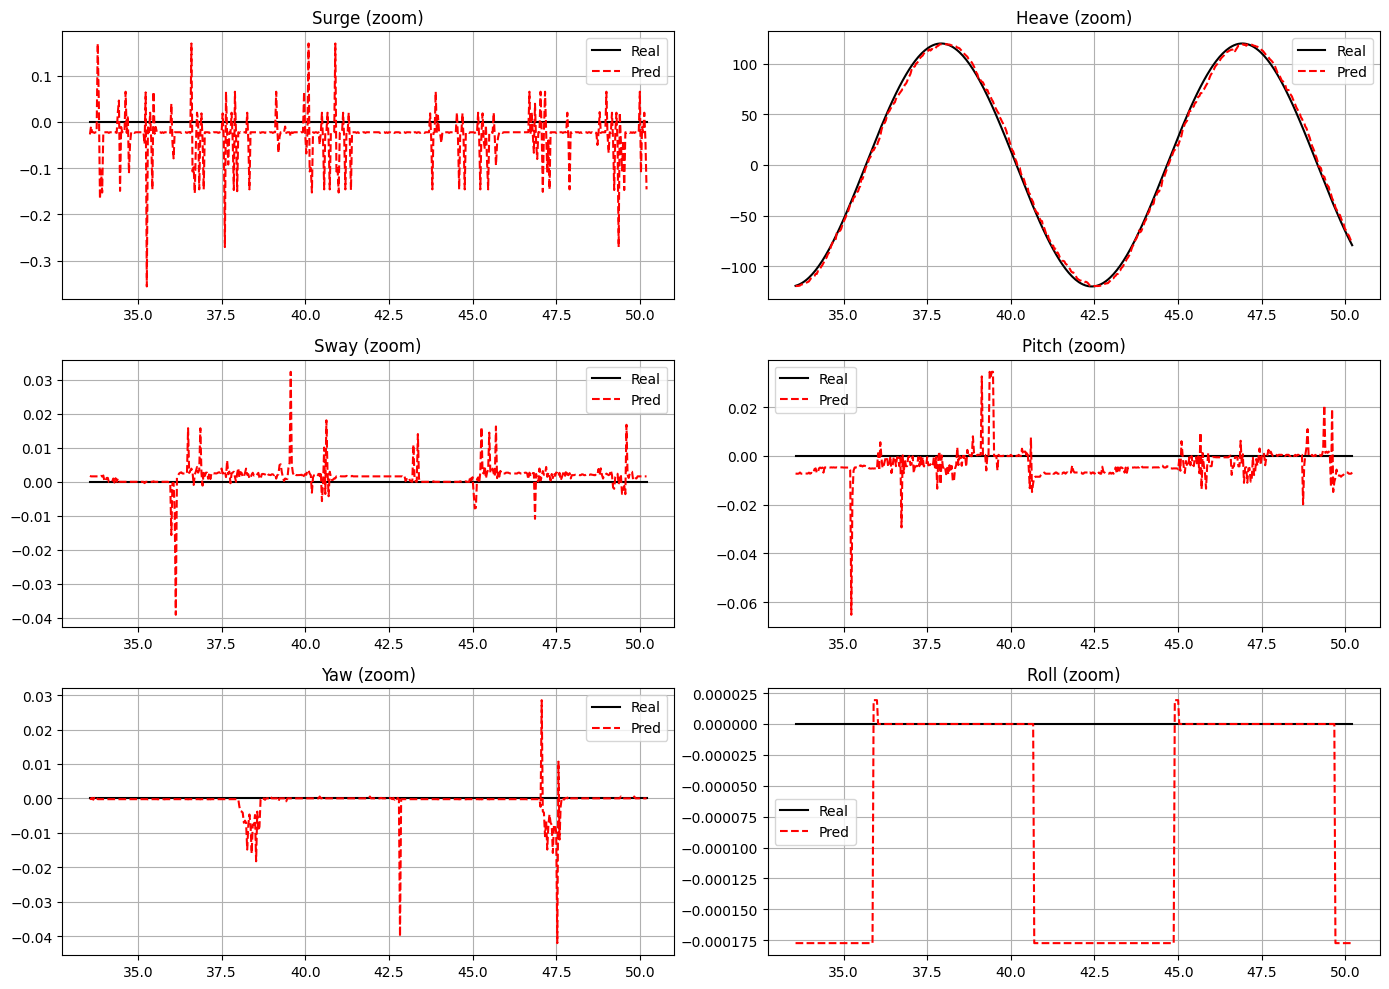

In [36]:
# =========================================================
# EVALUACIÓN SINUSOIDAL
# =========================================================

def willmott(y_true, y_pred):
    mean = np.mean(y_true)
    num = np.sum((y_true - y_pred)**2)
    den = np.sum((np.abs(y_pred - mean) + np.abs(y_true - mean))**2)
    return 1 - num/den if den != 0 else 0

video_test = "heave_amp_3_0_Tp9_sinusoidal" 

X_test = datos_prueba[video_test]['X']
y_test = datos_prueba[video_test]['y']
t = datos_prueba[video_test]['tiempo']

y_pred = modelo.predict(X_test)

nombres = ["Surge","Heave","Sway","Pitch","Yaw","Roll"]

fig, axes = plt.subplots(3,2, figsize=(14,10))
axes = axes.ravel()

for i in range(6):
    rmse = np.sqrt(mean_squared_error(y_test[:,i], y_pred[:,i]))
    w = willmott(y_test[:,i], y_pred[:,i])

    axes[i].plot(t, y_test[:,i], 'k', label="Real")
    axes[i].plot(t, y_pred[:,i], 'r--', label="Pred")
    axes[i].set_title(f"{nombres[i]} | RMSE={rmse:.3f} | W={w:.3f}")
    axes[i].grid()
    axes[i].legend()

plt.tight_layout()
plt.show()

# ZOOM PARA VER DETALLES
start = 1000
end = 1500

fig2, axes2 = plt.subplots(3,2, figsize=(14,10))
axes2 = axes2.ravel()

for i in range(6):
    axes2[i].plot(t[start:end], y_test[start:end,i], 'k', label="Real")
    axes2[i].plot(t[start:end], y_pred[start:end,i], 'r--', label="Pred")
    axes2[i].set_title(f"{nombres[i]} (zoom)")
    axes2[i].grid()
    axes2[i].legend()

plt.tight_layout()
plt.show()

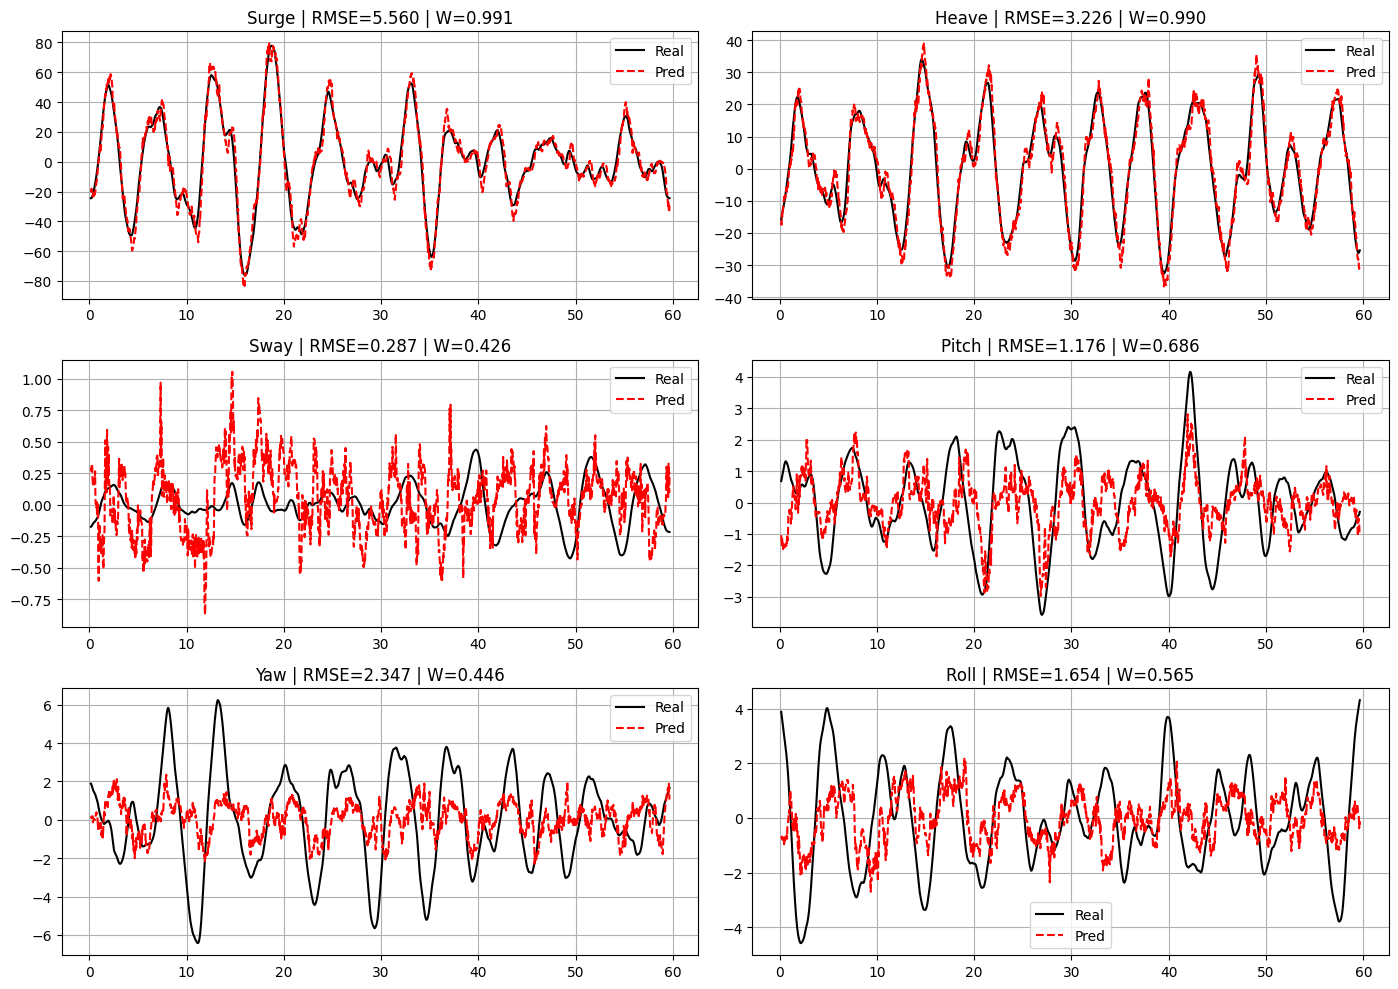

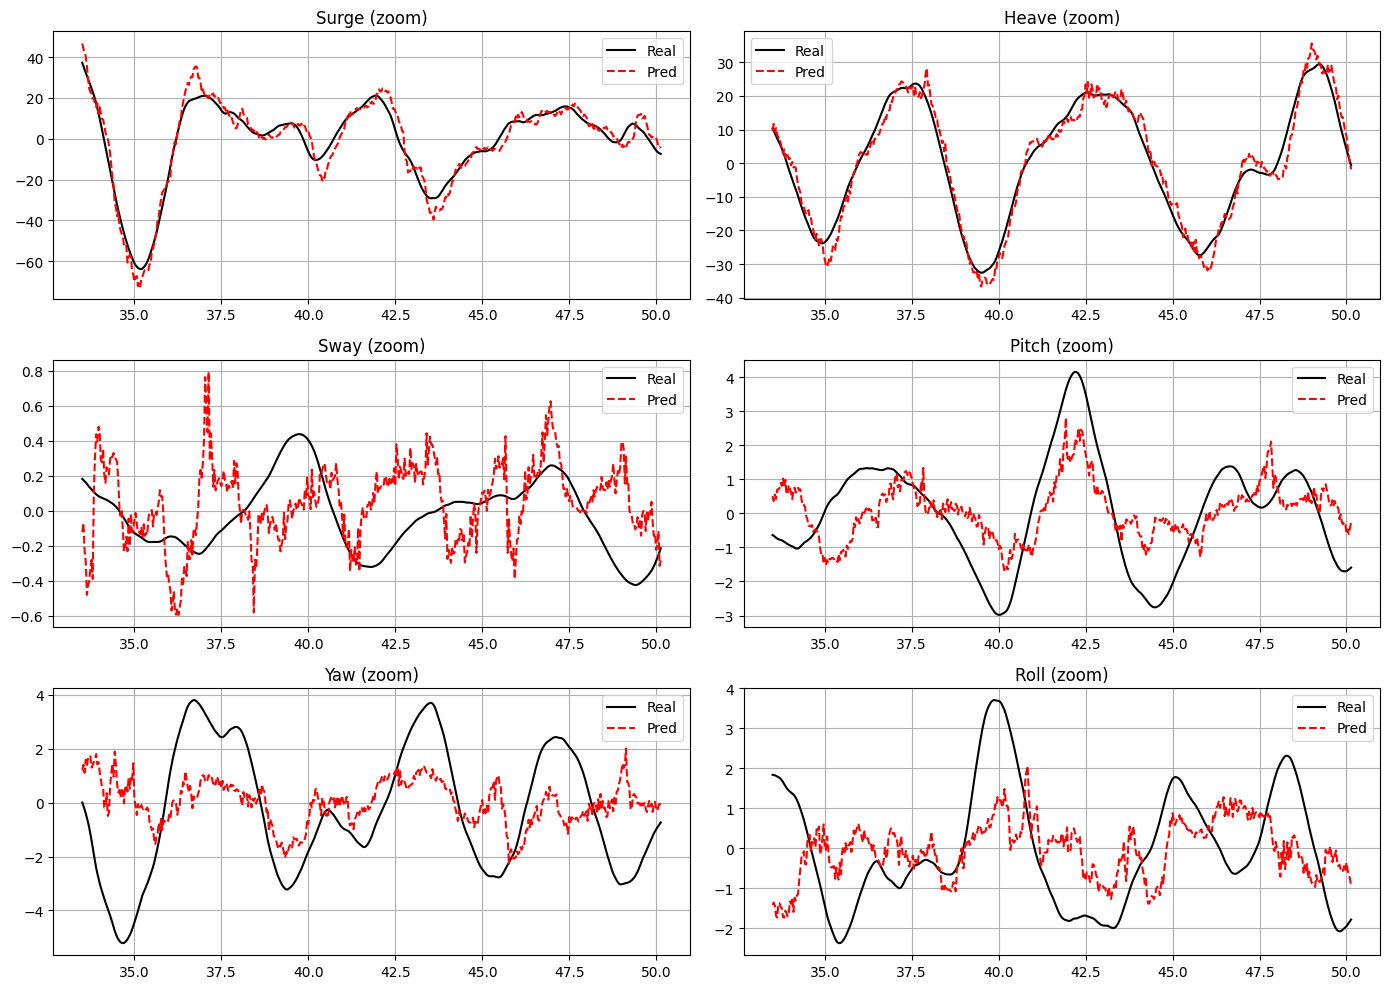

In [46]:
# =========================================================
# EVALUACIÓN COMPLETA
# =========================================================

def willmott(y_true, y_pred):
    mean = np.mean(y_true)
    num = np.sum((y_true - y_pred)**2)
    den = np.sum((np.abs(y_pred - mean) + np.abs(y_true - mean))**2)
    return 1 - num/den if den != 0 else 0

video_test = "video_0_Tp6"

X_test = datos_prueba[video_test]['X']
y_test = datos_prueba[video_test]['y']
t = datos_prueba[video_test]['tiempo']

y_pred = modelo.predict(X_test)

nombres = ["Surge","Heave","Sway","Pitch","Yaw","Roll"]

fig, axes = plt.subplots(3,2, figsize=(14,10))
axes = axes.ravel()

for i in range(6):
    rmse = np.sqrt(mean_squared_error(y_test[:,i], y_pred[:,i]))
    w = willmott(y_test[:,i], y_pred[:,i])

    axes[i].plot(t, y_test[:,i], 'k', label="Real")
    axes[i].plot(t, y_pred[:,i], 'r--', label="Pred")
    axes[i].set_title(f"{nombres[i]} | RMSE={rmse:.3f} | W={w:.3f}")
    axes[i].grid()
    axes[i].legend()

plt.tight_layout()
plt.show()

# ZOOM PARA DETALLES
start = 1000
end = 1500

fig2, axes2 = plt.subplots(3,2, figsize=(14,10))
axes2 = axes2.ravel()

for i in range(6):
    axes2[i].plot(t[start:end], y_test[start:end,i], 'k', label="Real")
    axes2[i].plot(t[start:end], y_pred[start:end,i], 'r--', label="Pred")
    axes2[i].set_title(f"{nombres[i]} (zoom)")
    axes2[i].grid()
    axes2[i].legend()

plt.tight_layout()
plt.show()